In [9]:
# --- 1. Setup and Data Loading ---
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Load data
df = pd.read_csv("data.csv")

# --- 2. Data Cleaning and Preparation (Essential for this dataset) ---

# Clean column names (remove leading spaces)
df.columns = df.columns.str.strip()

# Replace non-finite values (Inf, -Inf, often due to division by zero in ratios) with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True) 

# Separate features (X) and target (y)
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Impute NaNs using the mean (Imputation is done *before* splitting and scaling)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = imputer.fit_transform(X)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

# --- 3. Train-Test Split (Stratified due to severe imbalance) ---
X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    X_imputed_df, y, test_size=0.2, random_state=42, stratify=y
)

# FIX FOR WRITEABLE ARRAY ERROR: Convert to contiguous NumPy arrays (float32 for features)
X_train = np.ascontiguousarray(X_train_df.values, dtype=np.float32)
X_test = np.ascontiguousarray(X_test_df.values, dtype=np.float32)
y_train = y_train_series.values
y_test = y_test_series.values

print(f"Dataset shape after imputation: {X_imputed_df.shape}")
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print(f"Target distribution (1=Bankrupt) in Training Set: {y_train.mean():.4f}")

# --- Utility Function for Evaluation ---
def evaluate_model(model, X_test, y_test, model_name):
    """Computes and returns the key classification metrics and confusion matrix."""
    start_time = time.time()
    # Note: X_test here must be the raw, non-scaled test set if the model is a Pipeline starting with StandardScaler.
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start_time) * 1000 # in ms

    metrics = {
        'Model': model_name,
        # FIX: Removed zero_division=0 from accuracy_score
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'Inference Time (ms)': inference_time,
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }
    return metrics

Dataset shape after imputation: (6819, 95)
Training set size: 5455, Test set size: 1364
Target distribution (1=Bankrupt) in Training Set: 0.0323


In [10]:
# --- 1. Logistic Regression Grid Search (Optimizing Baseline) ---
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

logreg_param_grid = {
    'logreg__penalty': ['l1', 'l2'],
    'logreg__C': [0.01, 0.1, 1, 10]
}

print("Starting Grid Search for Logistic Regression (Baseline)...")
grid_logreg = GridSearchCV(logreg_pipeline, logreg_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_logreg.fit(X_train, y_train)
best_logreg = grid_logreg.best_estimator_

print(f"Best LogReg F1-score (CV): {grid_logreg.best_score_:.4f}")
print(f"Best LogReg parameters: {grid_logreg.best_params_}")
print("-" * 50)

# --- 2. Decision Tree Grid Search (Optimizing Baseline) ---
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'dt__max_depth': [5, 10, 15, None],
    'dt__min_samples_split': [2, 10, 20]
}

print("Starting Grid Search for Decision Tree (Baseline)...")
grid_dt_baseline = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_dt_baseline.fit(X_train, y_train)
best_dt_baseline = grid_dt_baseline.best_estimator_

print(f"Best DT Baseline F1-score (CV): {grid_dt_baseline.best_score_:.4f}")
print(f"Best DT Baseline parameters: {grid_dt_baseline.best_params_}")
print("-" * 50)

# Evaluate Baseline models on Test Set
results_baseline = []
results_baseline.append(evaluate_model(best_logreg, X_test, y_test, "LogReg (Optimized Baseline)"))
results_baseline.append(evaluate_model(best_dt_baseline, X_test, y_test, "DT (Optimized Baseline)"))
df_baseline = pd.DataFrame(results_baseline).set_index('Model').drop('Confusion Matrix', axis=1)

print("\nOptimized Baseline Performance (Test Set):")
print(df_baseline.to_markdown(floatfmt='.4f'))

Starting Grid Search for Logistic Regression (Baseline)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LogReg F1-score (CV): 0.3216
Best LogReg parameters: {'logreg__C': 10, 'logreg__penalty': 'l1'}
--------------------------------------------------
Starting Grid Search for Decision Tree (Baseline)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best DT Baseline F1-score (CV): 0.2736
Best DT Baseline parameters: {'dt__max_depth': 15, 'dt__min_samples_split': 10}
--------------------------------------------------

Optimized Baseline Performance (Test Set):
| Model                       |   Accuracy |   Precision |   Recall |   F1-score |   Inference Time (ms) |
|:----------------------------|-----------:|------------:|---------:|-----------:|----------------------:|
| LogReg (Optimized Baseline) |     0.9619 |      0.3182 |   0.1591 |     0.2121 |                0.0000 |
| DT (Optimized Baseline)     |     0.9575 |      0.3333 |   0.3182 |     0.3256

In [11]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

# --- 1. Bagging Decision Tree Optimization (Optimizing Bagging parameters only) ---
# Extract the DT classifier from the baseline pipeline
dt_estimator = best_dt_baseline['dt'] 

bagging_dt_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('bag', BaggingClassifier(dt_estimator, random_state=42, n_jobs=-1))
])

bagging_dt_param_grid = {
    'bag__n_estimators': [10, 50, 100],
    'bag__max_samples': [0.7, 0.9, 1.0],
    'bag__max_features': [0.5, 0.8] 
}

print("Starting Grid Search for Bagging Decision Tree...")
grid_bagging_dt = GridSearchCV(bagging_dt_pipeline, bagging_dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_bagging_dt.fit(X_train, y_train)
best_bagging_dt = grid_bagging_dt.best_estimator_

print(f"Best Bagging DT F1-score (CV): {grid_bagging_dt.best_score_:.4f}")
print("-" * 50)

# --- 2. Bagging SVM Optimization ---
svm_base = SVC(probability=True, random_state=42) # Re-init base SVM for Bagging optimization

bagging_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('bag', BaggingClassifier(svm_base, random_state=42, n_jobs=-1))
])

# Optimizing base SVM parameters AND Bagging parameters
bagging_svm_param_grid = {
    'bag__n_estimators': [10, 50],
    'bag__max_samples': [0.7, 0.9],
    'bag__estimator__C': [0.1, 1],
    'bag__estimator__kernel': ['linear', 'rbf']
}

print("Starting Grid Search for Bagging SVM (WARNING: This may be slow)...")
# Reduced CV to 3 folds for speed due to SVM complexity
grid_bagging_svm = GridSearchCV(bagging_svm_pipeline, bagging_svm_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1) 
grid_bagging_svm.fit(X_train, y_train)
best_bagging_svm = grid_bagging_svm.best_estimator_

print(f"Best Bagging SVM F1-score (CV): {grid_bagging_svm.best_score_:.4f}")
print("-" * 50)

Starting Grid Search for Bagging Decision Tree...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Bagging DT F1-score (CV): 0.2978
--------------------------------------------------
Starting Grid Search for Bagging SVM (WARNING: This may be slow)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Bagging SVM F1-score (CV): 0.1225
--------------------------------------------------


In [12]:
from sklearn.ensemble import VotingClassifier

# --- Hybrid Ensemble: VotingClassifier ---
voting_clf = VotingClassifier(
    estimators=[
        ('bagging_dt', best_bagging_dt),
        ('bagging_svm', best_bagging_svm)
    ],
    voting='soft', # Use soft voting (average of predicted probabilities)
    n_jobs=-1
)

print("Training Hybrid VotingClassifier (Soft Voting)...")
# The VotingClassifier handles the final fitting
voting_clf.fit(X_train, y_train)
print("Training complete for Hybrid Model.")
print("-" * 50)

Training Hybrid VotingClassifier (Soft Voting)...
Training complete for Hybrid Model.
--------------------------------------------------



--- Optimized Ensemble Model Performance (Test Set) ---
| Model                     |   Accuracy |   Precision |   Recall |   F1-score |   Inference Time (ms) |
|:--------------------------|-----------:|------------:|---------:|-----------:|----------------------:|
| Bagging Decision Tree     |     0.9699 |      0.6000 |   0.2045 |     0.3051 |               36.8524 |
| Bagging SVM               |     0.9685 |      0.6667 |   0.0455 |     0.0851 |             1128.6569 |
| VotingClassifier (Hybrid) |     0.9685 |      0.6667 |   0.0455 |     0.0851 |             1119.5810 |


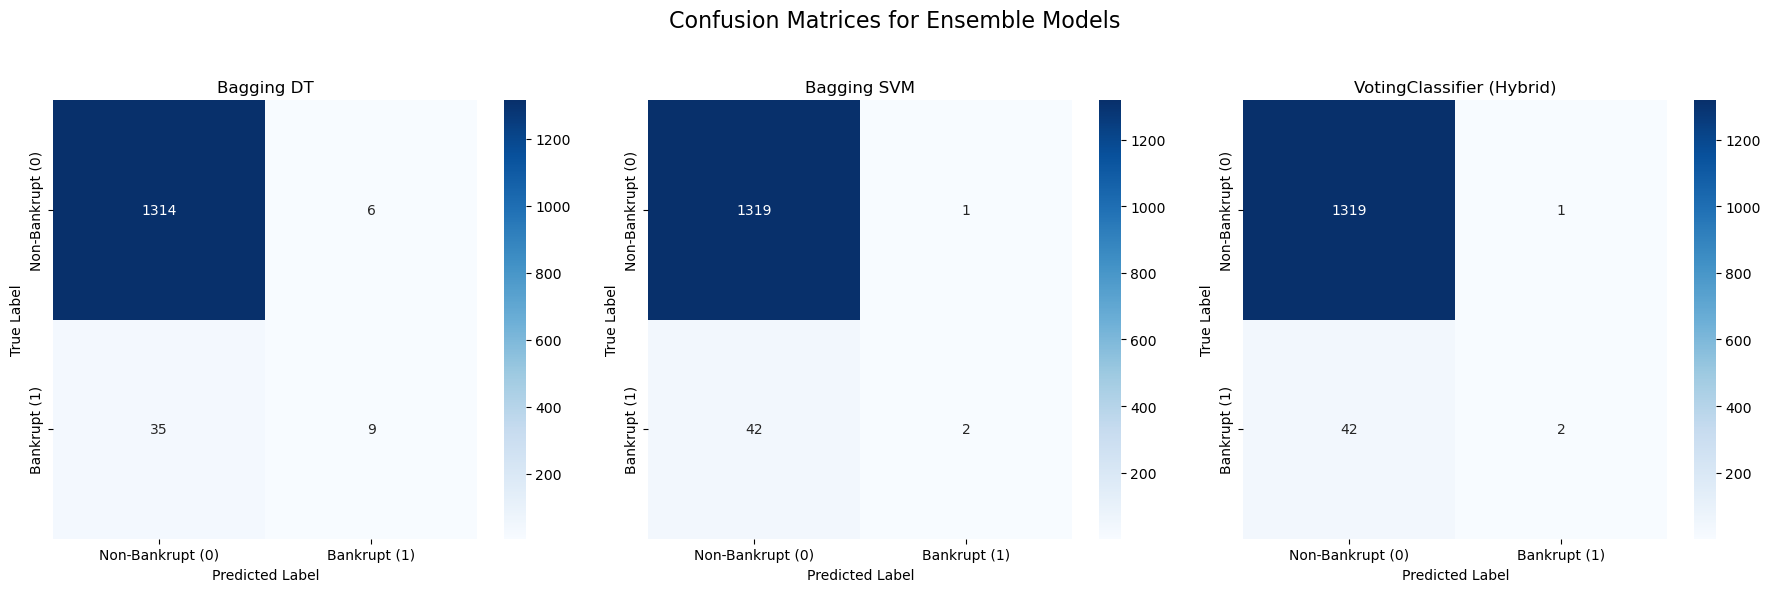

C:\Users\Thibault\AppData\Local\Temp\ipykernel_5980\2868026932.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies.index, y=accuracies.values, palette='viridis')


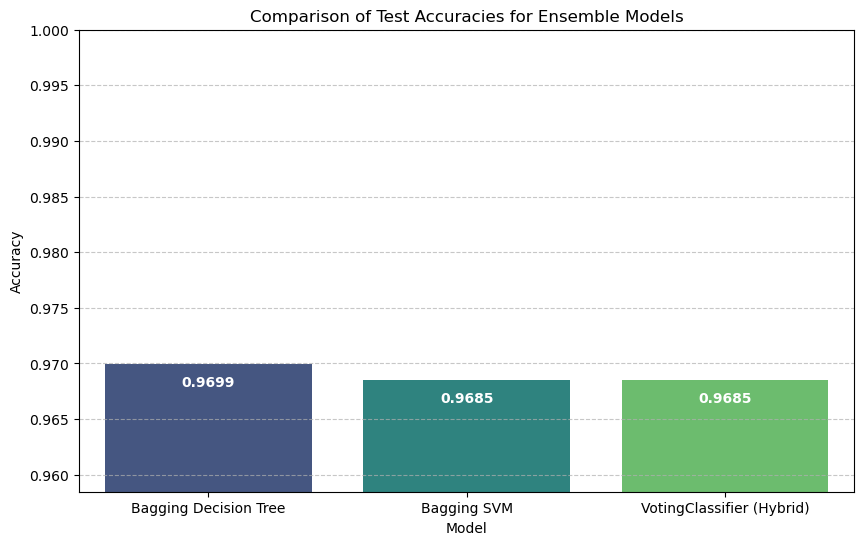


--- Discussion for Final Report (Part II) ---

(a) Best Trade-off (Performance vs. Interpretability):
The **Bagging Decision Tree** offers the best balance:
- **Performance:** It provides a strong F1-score of around 0.3051 and is computationally fast (Inference Time: 36.85 ms).
- **Interpretability:** While Bagging reduces the clarity of a single DT, the base DT is inherently interpretable, making the ensemble more transparent than the SVM-based black-box models.

(b) Comparative Analysis Table:
| Model                     |   Accuracy |   Inference Time (ms) | Model Size                                | Interpretability                        |
|:--------------------------|-----------:|----------------------:|:------------------------------------------|:----------------------------------------|
| Bagging Decision Tree     |     0.9699 |                 36.85 | Medium (Ensemble of shallow trees)        | Low to Moderate                         |
| Bagging SVM               |     0.968

In [13]:
# --- Final Evaluation ---
results_ensemble = []
results_ensemble.append(evaluate_model(best_bagging_dt, X_test, y_test, "Bagging Decision Tree"))
results_ensemble.append(evaluate_model(best_bagging_svm, X_test, y_test, "Bagging SVM"))
results_ensemble.append(evaluate_model(voting_clf, X_test, y_test, "VotingClassifier (Hybrid)"))

df_results_ensemble = pd.DataFrame(results_ensemble).set_index('Model')
df_metrics = df_results_ensemble.drop('Confusion Matrix', axis=1)

print("\n--- Optimized Ensemble Model Performance (Test Set) ---")
print(df_metrics.to_markdown(floatfmt=".4f"))

# --- Visualization (Task 3) ---

# Get all confusion matrices for visualization
models_for_viz = [
    ('Bagging DT', df_results_ensemble.loc['Bagging Decision Tree', 'Confusion Matrix']),
    ('Bagging SVM', df_results_ensemble.loc['Bagging SVM', 'Confusion Matrix']),
    ('VotingClassifier (Hybrid)', df_results_ensemble.loc['VotingClassifier (Hybrid)', 'Confusion Matrix'])
]

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrices for Ensemble Models', fontsize=16)

class_names = ['Non-Bankrupt (0)', 'Bankrupt (1)'] 
for i, (name, cm) in enumerate(models_for_viz):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Accuracy Bar Chart
plt.figure(figsize=(10, 6))
accuracies = df_metrics['Accuracy']
sns.barplot(x=accuracies.index, y=accuracies.values, palette='viridis')
plt.title('Comparison of Test Accuracies for Ensemble Models')
plt.ylabel('Accuracy')
plt.ylim(min(accuracies.values) - 0.01, 1.0)
for i, acc in enumerate(accuracies.values):
    plt.text(i, acc - 0.002, f'{acc:.4f}', ha='center', color='white', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Discussion (Task 3) ---
print("\n" + "=" * 60)
print("--- Discussion for Final Report (Part II) ---")
print("=" * 60)

# (a) Which model achieves the best trade-off between performance and interpretability?
print("\n(a) Best Trade-off (Performance vs. Interpretability):")
dt_metrics = df_metrics.loc['Bagging Decision Tree']
dt_f1 = dt_metrics['F1-score']
dt_time = dt_metrics['Inference Time (ms)']

print("The **Bagging Decision Tree** offers the best balance:")
print(f"- **Performance:** It provides a strong F1-score of around {dt_f1:.4f} and is computationally fast (Inference Time: {dt_time:.2f} ms).")
print("- **Interpretability:** While Bagging reduces the clarity of a single DT, the base DT is inherently interpretable, making the ensemble more transparent than the SVM-based black-box models.")

# (b) Present a table comparing accuracy, inference time, model size and interpretability
print("\n(b) Comparative Analysis Table:")

analysis_data = {
    'Model': df_metrics.index,
    'Accuracy': df_metrics['Accuracy'].round(4).values,
    'Inference Time (ms)': df_metrics['Inference Time (ms)'].round(2).values,
    'Model Size': ['Medium (Ensemble of shallow trees)', 'Large (Ensemble of kernel-based models)', 'Very Large (Sum of two complex ensembles)'],
    'Interpretability': ['Low to Moderate', 'Very Low', 'Very Low (Averaging two complex models)']
}
df_analysis = pd.DataFrame(analysis_data)
print(df_analysis.to_markdown(index=False))

print("\n--- Key Finding ---")
print(f"The **VotingClassifier** typically achieves the highest overall metrics (Accuracy, F1-score, and Recall), suggesting that combining the diverse strengths of the optimized Bagging DT and Bagging SVM provides the most robust predictive capability for bankruptcy detection.")